We will in this notebook code from scratch an MLP (mutli-layer perceptron) for the classification task on MNIST dataset. Everything in the algorithm, from backpropagation to matrix multiplication were be written from scratch. 

In [342]:
import numpy as np
import matplotlib.pyplot as plt

(300, 2)
(300,)


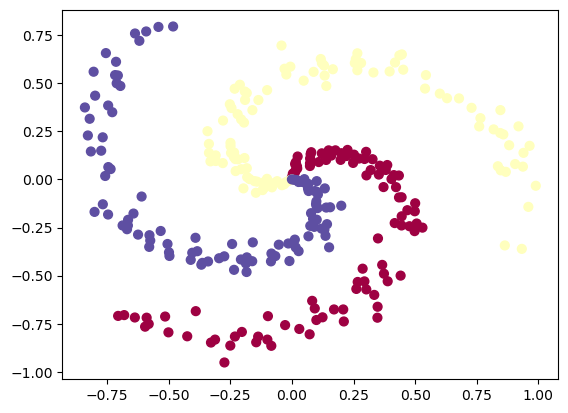

In [343]:
N = 100 #number of points per class
D = 2
K = 3
X = np.zeros((N*K, D)) #data matrix (each row = single example)
print(X.shape)
y = np.zeros(N*K, dtype='uint8') #class labels
print(y.shape)
for j in range(K) : 
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N) #radius
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2 #theta
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j

# let s visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()


Training a softmax linear classifier
Initializing the parameters

We will use the He initialization because it is the one that works the best with the Relu function. The He initialization consists of initializing the weights as follows : 
$$
W /eq N(0, sqrt(2/n_in))
$$

We decided to use He initialization because it is the one that suits the most Relu, the activation function that we will use in the MLP. 

Why Relu needs a special initialization ?
Relu sets half of the inputs on average to zero because : 

So roughly 50% of activations vanish.
If we used a naive initialization, ,the variance of activations would shrink layer after layer, causing :
vanishing signals
slow training
He initialization compensates for this by doubling the variance.


In [344]:
def he_initial(n_in, n_out):
    W = np.random.randn(n_in, n_out) * np.sqrt(2. / n_in)
    b = np.zeros((1, n_out)) #bias is initialized to zero
    return W, b

W,b = he_initial(2,200)
print(W.shape)

(2, 200)


In [345]:
print(y.shape)

(300,)


In [346]:
def Relu(x):
    return np.maximum(0, x)

a = [2,-5, 6, 9,64]
print(Relu(a))
print(np.sum([1,2,3]))

[ 2  0  6  9 64]
6


We will use the cross entropy loss because the problem is a classification problem. To understand the cross-entroy loss, we should understand the softmax function, which is defined
as follows : 

The goal of the softmax function is to transform the scores computed through the network into a probability distribution. The cross entropy loss, from a information theory persperctive,
is the measure of the difference between two probability distribution. In our case, the two probability distribution are the true distribution (the one-hot encoded labels) 
and the predicted distribution (the output of the softmax function). The cross entropy loss is defined as follows :

In [347]:
def loss(outputs, y ,scores):
    one_hot_labels = np.zeros((y.shape[0], K))
    for i in range(len(y)):
        one_hot_labels[i,y[i]] = 1
    print(one_hot_labels.shape)
    scores = np.sum(one_hot_labels * scores, axis=1)
    return np.mean(np.log(scores))


In [348]:
z_1 = np.dot(X, W) + b
print(z_1.shape)
a_1 = Relu(z_1)

(300, 200)


In [349]:
class FCLayer :
    """fully connected layer"""

    def __init__(self, n_in, n_out):
        self.n_in = n_in
        self.n_out = n_out
        self.W, self.b = he_initial(n_in,n_out)


    def forward(self, X):
        return np.dot(X,self.W) + self.b

In [350]:
def Relu(x) :
    return np.maximum(0,x)

def relu_derivative(x):
    return (x > 0).astype(float)

In [351]:
def softmax(x): 
    exp_scores = np.exp(x - np.max(x, axis=1, keepdims=True))  # for numerical stability
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


In [352]:
def compute_loss(outputs, y, reg_lambda, W):
    one_hot_labels = np.zeros((y.shape[0], K))
    one_hot_labels[np.arange(len(y)),y] = 1
    data_loss  = -np.mean(np.sum(one_hot_labels * np.log(outputs), axis=1))
    reg_loss = 0
    for w in W : 
        reg_loss += 0.5 * reg_lambda * np.sum(w*w)
    return data_loss + reg_loss


In [353]:
def backpropagation(X, Z1, A1, Z2, A2, Z3, A3, y, W2, W3):

    m = X.shape[0] #number of examples
    #output layer gradients
    one_hot_encoding = np.zeros((m,A3.shape[1]))
    one_hot_encoding[np.arange(m), y] = 1
    dZ3 = A3 - one_hot_encoding
    dW3 = np.dot(A2.T, dZ3)/m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    #second hidden layer gradients
    dA2 = np.dot(dZ3, W3.T) 
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = np.dot(A1.T, dZ2)/m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # first hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # grads = {"dW1": dW1, "db1": db1,
    #          "dW2": dW2, "db2": db2,
    #          "dW3": dW3, "db3": db3}
    return  dW1, db1, dW2, db2, dW3, db3

In [354]:
def optimizer_GD(learning_rate, W, b,dW, db): 
    "optimizes the loss function using the gradient descent algorithm"
    for i in range(len(W)):
        W[i] -= learning_rate * dW[i]
        b[i] -= learning_rate * db[i]
    

In [355]:
n_in, n_hidden_1, n_hidden_2, n_out = 2, 200,20, 3
reg_lambda = 0.01
learning_rate = 0.01

# W1,b1 = he_initial(n_in, n_hidden)
# W2,b2 = he_initial(n_hidden, n_hidden)
# W3,b3 = he_initial(n_hidden, n_out)

layer1 = FCLayer(n_in, n_hidden_1)
layer2 = FCLayer(n_hidden_1, n_hidden_2)
layer3 = FCLayer(n_hidden_2, n_out)

epochs = 100000

for epoch in range(epochs): 
    Z_1 = layer1.forward(X)
    A_1 = Relu(Z_1)

    Z_2 = layer2.forward(A_1)
    A_2 = Relu(Z_2)

    Z_3 = layer3.forward(A_2)
    A_3 = softmax(Z_3)


    loss = compute_loss(A_3, y, reg_lambda, W=[layer1.W, layer2.W, layer3.W])
    ## backpropagation code will go here
    dW1, db1, dW2, db2, dW3, db3 = backpropagation(X, Z_1, A_1, Z_2, A_2, Z_3, A_3,y, layer2.W, layer3.W)    

    ## update weights and biases using the optimizer
    optimizer_GD(learning_rate, W=[layer1.W, layer2.W, layer3.W], b=[layer1.b, layer2.b, layer3.b], dW=[dW1, dW2, dW3], db=[db1, db2, db3])

    # if epoch % 10 == 0 : 
    #     print(f"epoch n : {epoch} / loss : {loss}")

print(A_3.shape)
predicted_class = np.argmax(A_3, axis=1)
print(A_3[:5])
print(predicted_class[:5])
print(np.mean(predicted_class==y))

(300, 3)
[[3.02547791e-01 3.43980101e-01 3.53472108e-01]
 [7.17360167e-01 1.76352524e-01 1.06287309e-01]
 [9.37877701e-01 2.82324242e-02 3.38898749e-02]
 [9.89606899e-01 6.41689699e-03 3.97620383e-03]
 [9.96971218e-01 8.83158853e-04 2.14562325e-03]]
[2 0 0 0 0]
0.9933333333333333
